In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator

import cv2
from sklearn.model_selection import train_test_split
import os
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

In [2]:
# Paths
path = r"E:\milestone 3\Train"
labelFile = r"E:\milestone 3\train.csv"

# Parameters
batch_size_val = 32
epochs_val = 10
imageDimesions = (32, 32, 3)
testRatio = 0.2
validationRatio = 0.2

In [10]:
import os
import cv2
import numpy as np

# Fix the path
path = r"E:\milestone 3\Train"

images = []
classNo = []

# List all class folders
myList = os.listdir(path)
print("Total Classes Detected:", len(myList))
noOfClasses = len(myList)

# Loop through each class folder
for count, folder in enumerate(myList):
    folder_path = os.path.join(path, folder)
    myPicList = os.listdir(folder_path)
    
    for y in myPicList:
        curImg = cv2.imread(os.path.join(folder_path, y))
        if curImg is not None:  # check image is valid
            curImg = cv2.resize(curImg, (32, 32))   # resize to 32x32
            images.append(curImg)
            classNo.append(count)  # label is folder index
    
    print(count, end=" ")

print("\nImport Completed!")

images = np.array(images)
classNo = np.array(classNo)

print("Images shape:", images.shape)
print("Labels shape:", classNo.shape)


Total Classes Detected: 43
0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 
Import Completed!
Images shape: (39209, 32, 32, 3)
Labels shape: (39209,)


In [9]:
!pip install opencv-python


   ---------------------------------------- 0.0/39.0 MB ? eta -:--:--
   ---- ----------------------------------- 3.9/39.0 MB 21.2 MB/s eta 0:00:02
   ---------- ----------------------------- 10.5/39.0 MB 26.4 MB/s eta 0:00:02
   ------------------ --------------------- 17.6/39.0 MB 28.6 MB/s eta 0:00:01
   -------------------------- ------------- 25.4/39.0 MB 30.7 MB/s eta 0:00:01
   ------------------------------ --------- 29.6/39.0 MB 28.4 MB/s eta 0:00:01
   -------------------------------------- - 37.2/39.0 MB 29.2 MB/s eta 0:00:01
   ---------------------------------------- 39.0/39.0 MB 27.0 MB/s  0:00:01
   ---------------------------------------- 0.0/12.6 MB ? eta -:--:--
   ------------------------- -------------- 8.1/12.6 MB 38.7 MB/s eta 0:00:01
   ---------------------------------------- 12.6/12.6 MB 35.3 MB/s  0:00:00

  Attempting uninstall: numpy

    Found existing installation: numpy 2.3.3

   ---------------------------------------- 0/2 [numpy]
   --------------------

  You can safely remove it manually.
  You can safely remove it manually.


In [15]:
import os
import cv2
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split   # ✅ import added

# Example ratios (set them before using)
testRatio = 0.2         # 20% for test
validationRatio = 0.2   # 20% of remaining train for validation

# Split data into train/test
X_train, X_test, y_train, y_test = train_test_split(
    images, classNo, test_size=testRatio, random_state=42, stratify=classNo
)

# Split training further into train/validation
X_train, X_validation, y_train, y_validation = train_test_split(
    X_train, y_train, test_size=validationRatio, random_state=42, stratify=y_train
)

print("Data Shapes")
print("Train:", X_train.shape, y_train.shape)
print("Validation:", X_validation.shape, y_validation.shape)
print("Test:", X_test.shape, y_test.shape)

# ✅ Load label file (make sure you set the correct path!)
labelFile = r"E:\milestone 3\labels.csv"   # <-- change this to your actual labels file path
data = pd.read_csv(labelFile)
print("Label Data shape:", data.shape)


Data Shapes
Train: (25093, 32, 32, 3) (25093,)
Validation: (6274, 32, 32, 3) (6274,)
Test: (7842, 32, 32, 3) (7842,)


FileNotFoundError: [Errno 2] No such file or directory: 'E:\\milestone 3\\labels.csv'

In [14]:
!pip install scikit-learn


   ---------------------------------------- 0.0/8.7 MB ? eta -:--:--
   ------- -------------------------------- 1.6/8.7 MB 7.7 MB/s eta 0:00:01
   --------------- ------------------------ 3.4/8.7 MB 8.9 MB/s eta 0:00:01
   ---------------------------- ----------- 6.3/8.7 MB 10.1 MB/s eta 0:00:01
   ---------------------------------------- 8.7/8.7 MB 11.0 MB/s  0:00:00
   ---------------------------------------- 0.0/38.5 MB ? eta -:--:--
   --- ------------------------------------ 3.1/38.5 MB 15.7 MB/s eta 0:00:03
   ------- -------------------------------- 7.3/38.5 MB 17.4 MB/s eta 0:00:02
   ------------ --------------------------- 11.8/38.5 MB 18.6 MB/s eta 0:00:02
   --------------- ------------------------ 14.9/38.5 MB 19.6 MB/s eta 0:00:02
   -------------------- ------------------- 20.2/38.5 MB 18.9 MB/s eta 0:00:01
   --------------------------- ------------ 26.2/38.5 MB 21.2 MB/s eta 0:00:01
   ---------------------------------- ----- 32.8/38.5 MB 22.1 MB/s eta 0:00:01
   ----

In [16]:
def preprocessing(img):
    img = img / 255.0   # normalize RGB values between 0-1
    return img

X_train = np.array(list(map(preprocessing, X_train)))
X_validation = np.array(list(map(preprocessing, X_validation)))
X_test = np.array(list(map(preprocessing, X_test)))

# Data Augmentation
dataGen = ImageDataGenerator(width_shift_range=0.1,
                             height_shift_range=0.1,
                             zoom_range=0.2,
                             shear_range=0.1,
                             rotation_range=10)
dataGen.fit(X_train)

# One-hot encode labels
y_train = to_categorical(y_train, noOfClasses)
y_validation = to_categorical(y_validation, noOfClasses)
y_test = to_categorical(y_test, noOfClasses)

In [17]:
def myModel():
    model = Sequential()
    model.add(Conv2D(60, (5,5), input_shape=imageDimesions, activation='relu'))
    model.add(Conv2D(60, (5,5), activation='relu'))
    model.add(MaxPooling2D(pool_size=(2,2)))

    model.add(Conv2D(30, (3,3), activation='relu'))
    model.add(Conv2D(30, (3,3), activation='relu'))
    model.add(MaxPooling2D(pool_size=(2,2)))
    model.add(Dropout(0.5))

    model.add(Flatten())
    model.add(Dense(500, activation='relu'))
    model.add(Dropout(0.5))
    model.add(Dense(noOfClasses, activation='softmax'))

    model.compile(Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])
    return model

In [18]:
model = myModel()
print(model.summary())

history = model.fit(
    dataGen.flow(X_train, y_train, batch_size=batch_size_val),
    epochs=epochs_val,
    validation_data=(X_validation, y_validation),
    shuffle=True
)

E:\milestone 3\jupyter\venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 28, 28, 60)          │           4,560 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 24, 24, 60)          │          90,060 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 12, 12, 60)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 10, 10, 30)          │          16,230 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 8, 8, 30)            │           8,130 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 4, 4, 30)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 4, 4, 30)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 480)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 500)                 │         240,500 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 500)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 43)                  │          21,543 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 381,023 (1.45 MB)

 Trainable params: 381,023 (1.45 MB)

 Non-trainable params: 0 (0.00 B)

None


E:\milestone 3\jupyter\venv\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
785/785 ━━━━━━━━━━━━━━━━━━━━ 87s 104ms/step - accuracy: 0.3173 - loss: 2.3975 - val_accuracy: 0.7375 - val_loss: 0.8455
Epoch 2/10
785/785 ━━━━━━━━━━━━━━━━━━━━ 84s 106ms/step - accuracy: 0.6297 - loss: 1.1708 - val_accuracy: 0.9187 - val_loss: 0.3043
Epoch 3/10
785/785 ━━━━━━━━━━━━━━━━━━━━ 85s 108ms/step - accuracy: 0.7574 - loss: 0.7755 - val_accuracy: 0.9468 - val_loss: 0.1844
Epoch 4/10
785/785 ━━━━━━━━━━━━━━━━━━━━ 83s 106ms/step - accuracy: 0.8126 - loss: 0.5916 - val_accuracy: 0.9656 - val_loss: 0.1361
Epoch 5/10
785/785 ━━━━━━━━━━━━━━━━━━━━ 77s 97ms/step - accuracy: 0.8491 - loss: 0.4875 - val_accuracy: 0.9802 - val_loss: 0.0885
Epoch 6/10
785/785 ━━━━━━━━━━━━━━━━━━━━ 80s 101ms/step - accuracy: 0.8720 - loss: 0.4078 - val_accuracy: 0.9788 - val_loss: 0.0895
Epoch 7/10
785/785 ━━━━━━━━━━━━━━━━━━━━ 77s 98ms/step - accuracy: 0.8890 - loss: 0.3584 - val_accuracy: 0.9839 - val_loss: 0.0592
Epoch 8/10
785/785 ━━━━━━━━━━━━━━━━━━━━ 75s 96ms/step - accuracy: 0.8996 - loss: 0.32

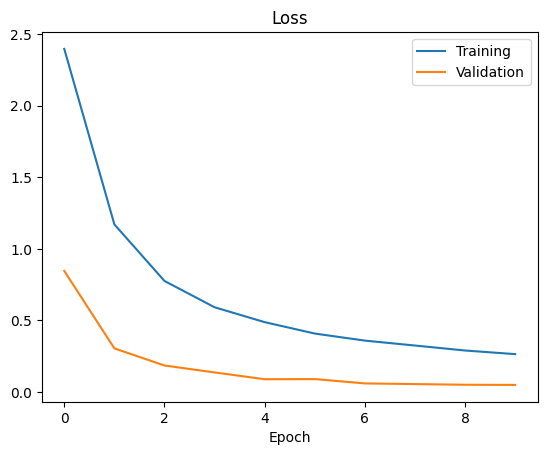

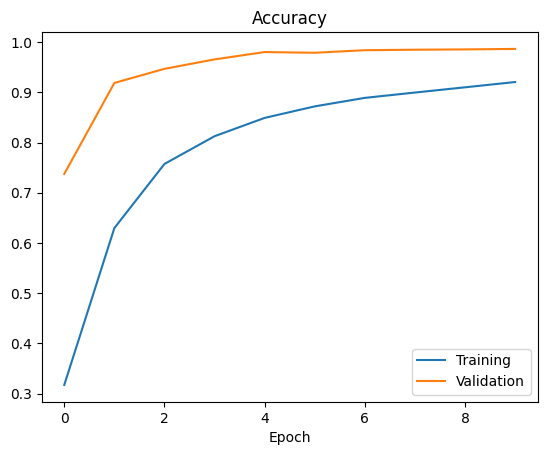

In [19]:
# Training & Validation Curves

plt.figure(1)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.legend(['Training', 'Validation'])
plt.title('Loss')
plt.xlabel('Epoch')

plt.figure(2)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.legend(['Training', 'Validation'])
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.show()

In [20]:
# Evaluate model

score = model.evaluate(X_test, y_test, verbose=0)
print('Test Score:', score[0])
print('Test Accuracy:', score[1])

Test Score: 0.046026624739170074
Test Accuracy: 0.9858454465866089


In [23]:
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# Predictions
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

# Convert one-hot encoded y_test to integers
y_true = np.argmax(y_test, axis=1)

# Metrics
accuracy = accuracy_score(y_true, y_pred_classes)
precision = precision_score(y_true, y_pred_classes, average="weighted")
recall = recall_score(y_true, y_pred_classes, average="weighted")
f1 = f1_score(y_true, y_pred_classes, average="weighted")

print("\n Model Performance Metrics")
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-Score  : {f1:.4f}")

print("\n Detailed Classification Report:\n")
print(classification_report(y_true, y_pred_classes, digits=4))


246/246 ━━━━━━━━━━━━━━━━━━━━ 8s 30ms/step

 Model Performance Metrics
Accuracy  : 0.9858
Precision : 0.9861
Recall    : 0.9858
F1-Score  : 0.9857

 Detailed Classification Report:

              precision    recall  f1-score   support

           0     0.9750    0.9286    0.9512        42
           1     0.9865    0.9842    0.9853       444
           2     0.9901    0.9975    0.9938       402
           3     0.9458    0.9924    0.9686       264
           4     0.9976    1.0000    0.9988       420
           5     1.0000    0.9954    0.9977       432
           6     1.0000    1.0000    1.0000       156
           7     1.0000    1.0000    1.0000       126
           8     1.0000    1.0000    1.0000        84
           9     1.0000    1.0000    1.0000       222
          10     0.9877    1.0000    0.9938       240
          11     1.0000    0.9048    0.9500        42
          12     0.9867    0.9867    0.9867       450
          13     1.0000    0.9722    0.9859        72
        

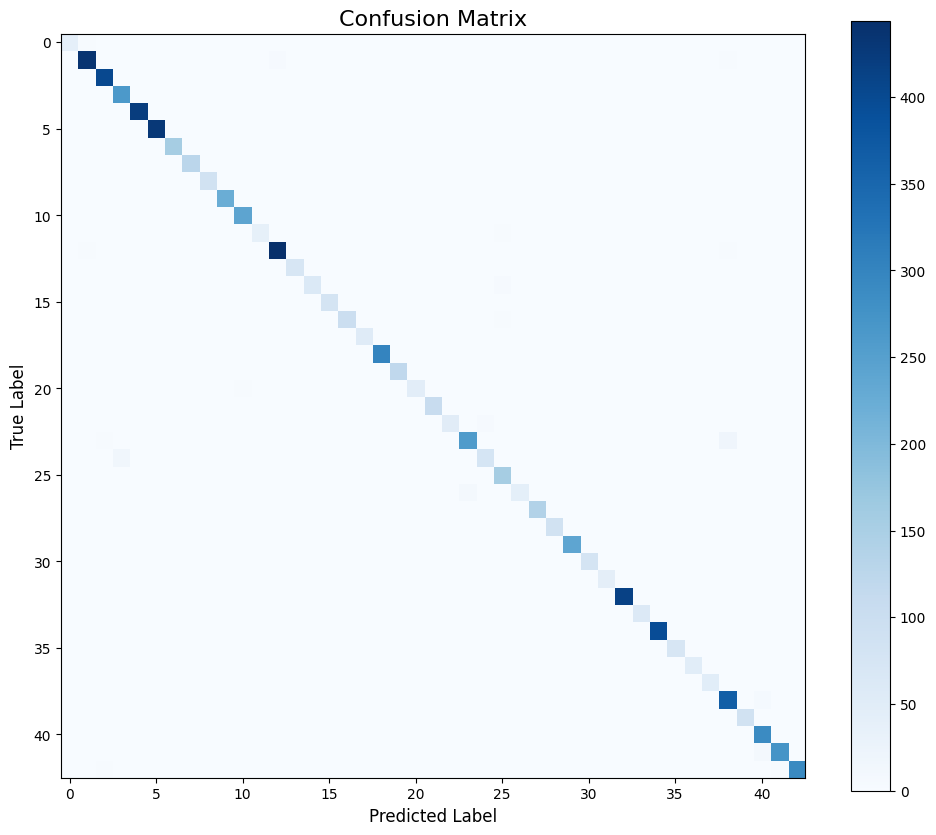

In [25]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(12, 10))
plt.imshow(cm, cmap="Blues")
plt.colorbar()
plt.title("Confusion Matrix", fontsize=16)
plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("True Label", fontsize=12)
plt.show()


In [26]:
# Save Model

model.save("model_rgb.h5")
print("Model saved as model_rgb.h5")

Model saved as model_rgb.h5
